STEP 1 - google mount drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


STEP 2 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

STEP 3 — Upload Your Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mnist_test.csv.zip to mnist_test.csv.zip


STEP 4 — Extract Dataset

In [ ]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/mnist')

print("Dataset extracted successfully!")
print(os.listdir('/content/mnist'))

Dataset extracted successfully!
['mnist_test.csv']


STEP 5 — Load Dataset

In [ ]:
df = pd.read_csv('/content/mnist/mnist_test.csv')

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(10000, 785)


STEP 6 — View Dataset

In [ ]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Then:

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 785
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 59.9 MB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 59.9 MB


STEP 7 — Check Missing Values

In [ ]:
print("Missing values:", df.isnull().sum().sum())
print(df['label'].value_counts().sort_index())

Missing values: 0
label
0     980
1    1135
2    1032
3    1010
4     982
5     892
6     958
7    1028
8     974
9    1009
Name: count, dtype: int64


STEP 8 — Separate Label and Pixel Data

In [ ]:
X = df.drop('label', axis=1)
y = df['label']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (10000, 784)
Labels shape: (10000,)


STEP 9 — Normalize Pixel Values

MNIST pixel values are between 0 and 255.

In [ ]:
X = X / 255.0

Check:

In [ ]:
print("Minimum pixel value:", X.min().min())
print("Maximum pixel value:", X.max().max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


STEP 10 — Reshape Images

In [ ]:
X = X.values.reshape(-1, 28, 28, 1)

print("New shape:", X.shape)

New shape: (10000, 28, 28, 1)


STEP 11 — Visualize Handwritten Digits

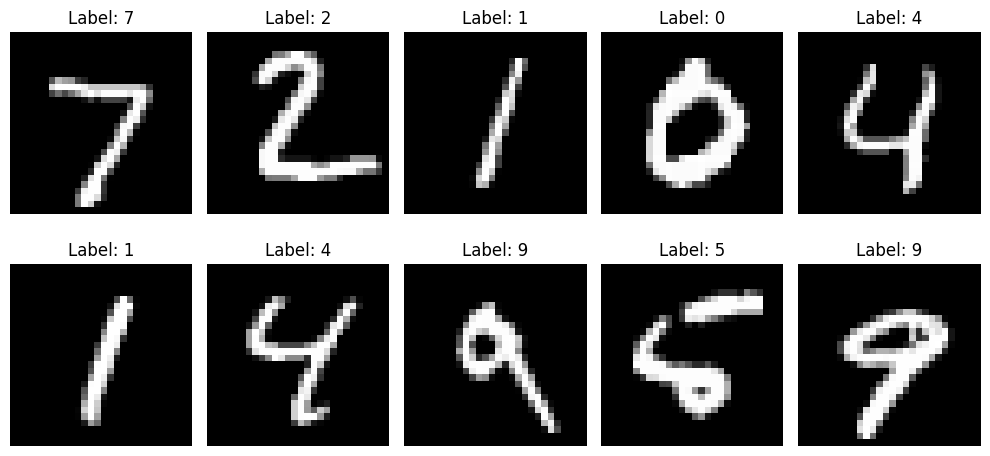

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y.iloc[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

STEP 12 — Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 28, 28, 1)
Testing data: (2000, 28, 28, 1)


STEP 13 — Build CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(28, 28, 1)), # Explicitly define input layer
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

STEP 14 — Compile CNN

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

STEP 15 — Train the Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.7332 - loss: 0.8260 - val_accuracy: 0.9337 - val_loss: 0.2154
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.9328 - loss: 0.2431 - val_accuracy: 0.9575 - val_loss: 0.1498
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.9472 - loss: 0.1724 - val_accuracy: 0.9625 - val_loss: 0.1170
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.9574 - loss: 0.1403 - val_accuracy: 0.9688 - val_loss: 0.0957
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.9669 - loss: 0.1069 - val_accuracy: 0.9737 - val_loss: 0.0770
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.9721 - loss: 0.0908 - val_accuracy: 0.9725 - val_loss: 0.0821
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9747 - loss: 0.0777 - val_accuracy: 0.9775 - val_loss: 0.0677
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.9768 - loss: 0.0736 - val_ac

STEP 16 — Plot Accuracy and Loss





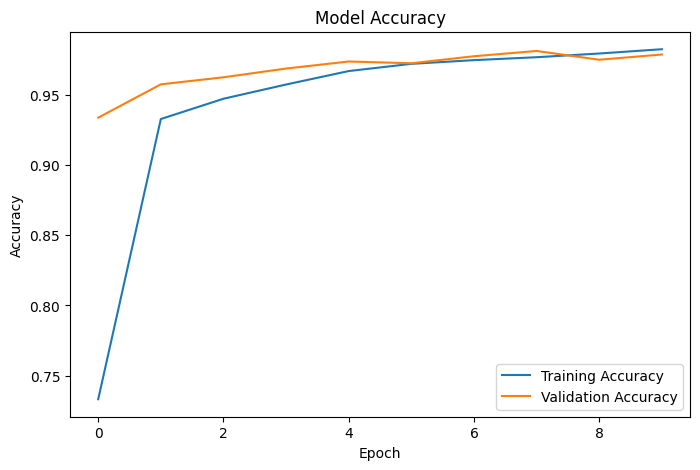

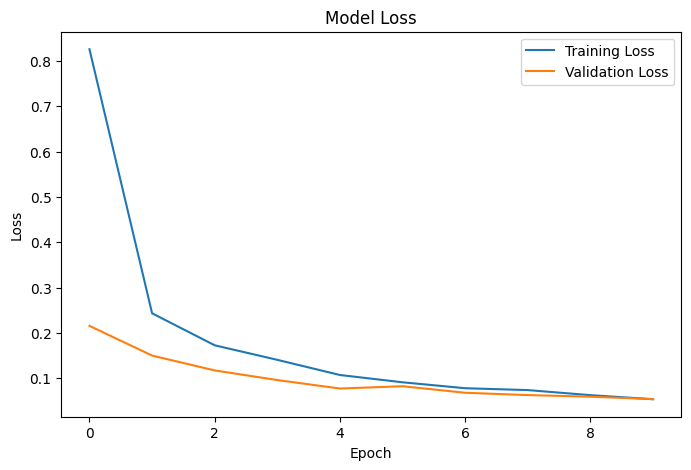

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

STEP 17 — Evaluate Model

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9765 - loss: 0.0622
Test Accuracy: 0.9764999747276306
Test Loss: 0.06223959103226662


STEP 18 — Make Predictions

In [ ]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[:20])
print("Actual:   ", y_test.iloc[:20].values)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Predicted: [1 2 4 2 1 0 6 6 6 6 0 8 4 9 8 7 6 8 0 7]
Actual:    [1 2 4 2 1 0 6 6 6 6 0 8 4 9 8 7 6 8 0 7]


STEP 20 — Confusion Matrix

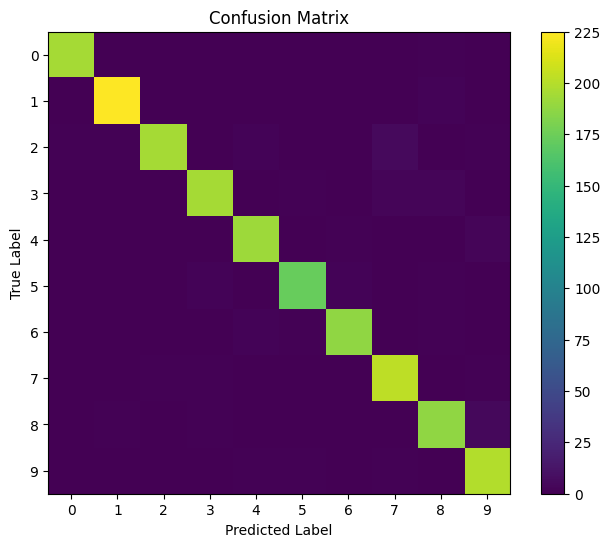

In [ ]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.show()

STEP 21 — Classification Report

In [ ]:
print(classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       196
           1       0.99      0.99      0.99       227
           2       0.99      0.95      0.97       206
           3       0.98      0.97      0.97       202
           4       0.97      0.98      0.98       196
           5       0.98      0.97      0.98       178
           6       0.98      0.98      0.98       192
           7       0.95      0.99      0.97       206
           8       0.96      0.96      0.96       195
           9       0.95      0.99      0.97       202

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



STEP 22 — Show Predictions Visually

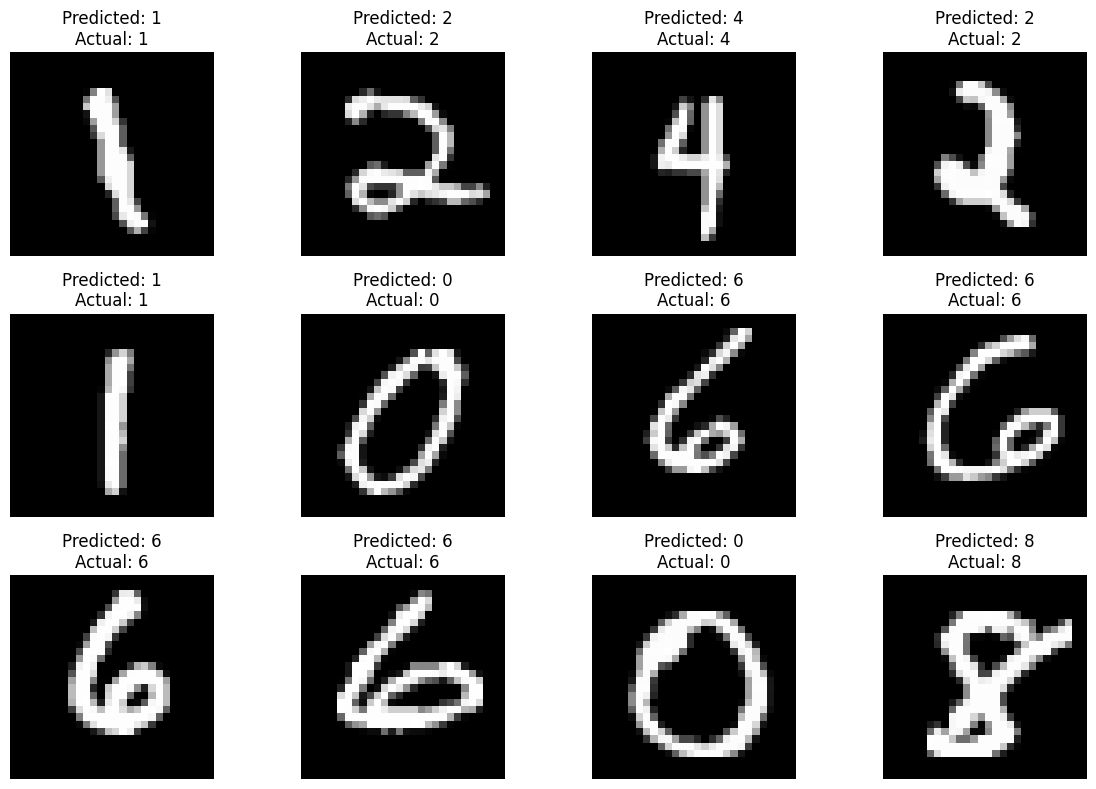

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(
        f"Predicted: {predicted_labels[i]}\nActual: {y_test.iloc[i]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

STEP 23 — Save the Model

In [ ]:
model.save('handwritten_digit_cnn.h5')

print("Model saved successfully!")

Model saved successfully!
